# Getting Started

You do not need to install Python or any packages on your computer.
This notebook will set up the course environment automatically in Google Colab.

### Setup

Run the cells below once when you start a new Colab runtime (or the notebook restarts)

The setup will:

1. Download the course repository.
2. Recreate the Python environment from the course's locked dependencies.
3. Create the course data directories.
4. Check that everything is working.

This may take a few minutes the first time.

__WARNING!__

The colab runtime environment will crash and restart after you run the first cell below. This is expected, so just reconnect and run the first cell again. This time it will be much faster and won't crash.

In [3]:
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    marker = Path("/content/.course_setup_done")
    if not marker.exists():
        subprocess.run(
            ["wget", "-q",
             "https://raw.githubusercontent.com/kaancet/2026KU-invivo/main/setup_colab.py"],
            check=True,
        )
        subprocess.run([sys.executable, "setup_colab.py", "--download-data"], check=True)
        marker.touch()
        print("\nSetup complete. Restarting the runtime to load the new packages.")
        print("After it restarts, run this cell again (it will skip), then continue.")
        os.kill(os.getpid(), 9)   # forces a clean Colab kernel restart
    else:
        print("Setup already done for this runtime.")


In [4]:
# Locate the course data (downloaded into the repo in Colab; repo/data locally).
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    DATA_ROOT = Path("/content/2026KU-invivo/data")
except ModuleNotFoundError:
    DATA_ROOT = Path(sys.executable).parents[2] / "data"

DATA_PATH = DATA_ROOT / "processed"
assert DATA_PATH.exists(), f"Data not found: {DATA_PATH} (run the setup cell above first)"
print("Data path:", DATA_PATH)


Data path: /Users/kaan/code/2026KU-invivo/data/processed


## 1. Loading and exploring the preprocessed data

In the below code snippet we load the behavioral data saved as a .parquet file. And look at it's first 5 rows

The data is in the form of a [polars](https://docs.pola.rs/api/python/stable/reference/index.html) DataFrame. A DataFrame has named _columns_ that correspond to features in the data and _rows_ that correspond to samples, which in our case are individual trials.

In [5]:
import polars as pl

behavioral_data = pl.read_parquet(f"{DATA_PATH}/260128_experiment_data.parquet")
behavioral_data.head()

total_trial_no,trial_no,t_trialstart,t_trialend,reward,lick,t_vstimstart_rig,t_vstimend_rig,t_vstimstart,t_vstimend,vstim_time_diff,state_time_diff,outcome,wheel_t,wheel_pos,reaction_time,peak_speed,isCatch,t_trialinit,duration_quiescence,duration_blank,state_outcome,state_response_time,iTrial,prob,opto,opto_pattern,total_iStim,corrected_presentTime,contrast,sf,tf,stim_pos,median_loop_time,rig_response_tick,rig_response_time,opto_pulse,…,stat_early_trial_count,stat_stim_trial_count,stat_correct_trial_count,stat_miss_trial_count,stat_catch_trial_count,stat_opto_trial_count,stat_opto_ratio,stat_nonopto_hit_rate,stat_correct_rate,stat_hit_rate,stat_false_alarm_rate,stat_nogo_rate,stat_median_response_time,stat_median_reaction_time,stat_d_prime,stat_easy_trial_count,stat_easy_hit_rate,stat_easy_nogo_rate,stat_easy_median_response_time,stat_easy_median_reaction_time,opto_ratio,opto_targets,stimulus_count,stim_combination,isTitrated,rig,session_id,session_path,user,opto_power,imaging,paradigm,area,isCNO,contrast_vector,sf_values,tf_values
i64,u64,u64,u64,list[f64],list[f64],u64,u64,u64,u64,f64,f64,str,list[f64],list[i64],f64,f64,bool,f64,f64,f64,i64,f64,i64,f64,bool,i64,i64,list[f64],f64,f64,f64,i64,f64,i64,f64,list[f64],…,i32,i32,i32,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64,i32,i32,str,bool,str,i32,str,str,str,str,str,str,bool,list[f64],list[f64],list[f64]
1,1,2099,4249,"[3697.0, 41.0]","[3641.0, 3743.0, … 4181.0]",2982,3741,2982,3732,-34.508,-40.0,"""hit""","[3040.0, 3513.0, … 4003.0]","[-4152, -4150, … -4105]",533.2,6.365377,false,2449.0,349.0,528.0,1,633.0,1,0.1125,false,-1,1,"[2982.0, 2998.607, … 3732.067]",0.125,0.08,2.0,37,16.658,null,null,[],…,15,172,50,122,13,69,34.5,43.689,25.0,29.07,7.5,70.93,332.0,235.6,0.888191,53,66.038,33.962,315.0,224.0,0.5,1,1,"""0.08cpd_2.0Hz""",false,"""rig3""",4229456,"""/Users/kaan/data/presentation/…","""KC""","""na""","""na""","""na""","""V1""",false,"[0.5, 0.125, 0.0]",[0.08],[2.0]
2,2,4209,10842,[],"[4297.0, 4418.0, … 7726.0]",null,null,null,null,0.0,0.0,"""early""","[4320.0, 4403.0, … 9223.0]","[-4107, -4109, … -4333]",-956.4,7.251624,false,6392.0,2182.0,2759.0,-1,-839.0,null,null,false,-1,null,[],null,null,null,null,null,null,null,[],…,15,172,50,122,13,69,34.5,43.689,25.0,29.07,7.5,70.93,332.0,235.6,0.888191,53,66.038,33.962,315.0,224.0,0.5,1,1,"""0.08cpd_2.0Hz""",false,"""rig3""",4229456,"""/Users/kaan/data/presentation/…","""KC""","""na""","""na""","""na""","""V1""",false,"[0.5, 0.125, 0.0]",[0.08],[2.0]
3,3,10882,13632,"[13080.0, 41.0]","[13007.0, 13104.0, … 13565.0]",12632,13124,12632,13115,-34.349,-40.0,"""hit""","[12145.0, 12637.0, … 13562.0]","[-4330, -4329, … -4220]",290.8,10.792206,false,11232.0,349.0,1398.0,1,366.0,3,0.1125,false,-1,3,"[12632.0, 12649.551, … 13115.457]",0.5,0.08,2.0,37,16.679,null,null,[],…,15,172,50,122,13,69,34.5,43.689,25.0,29.07,7.5,70.93,332.0,235.6,0.888191,53,66.038,33.962,315.0,224.0,0.5,1,1,"""0.08cpd_2.0Hz""",false,"""rig3""",4229456,"""/Users/kaan/data/presentation/…","""KC""","""na""","""na""","""na""","""V1""",false,"[0.5, 0.125, 0.0]",[0.08],[2.0]
4,4,13632,17533,"[16980.0, 41.0]","[13687.0, 13817.0, … 17445.0]",16732,17024,16732,17016,-34.265,-40.0,"""early""","[13597.0, 13692.0, … 17474.0]","[-4222, -4224, … -4470]",-169.4,5.595152,false,15498.0,1866.0,1220.0,1,167.0,4,0.1125,false,-1,4,"[16732.0, 16748.669, … 17015.327]",0.125,0.08,2.0,37,16.66,null,null,[],…,15,172,50,122,13,69,34.5,43.689,25.0,29.07,7.5,70.93,332.0,235.6,0.888191,53,66.038,33.962,315.0,224.0,0.5,1,1,"""0.08cpd_2.0Hz""",false,"""rig3""",4229456,"""/Users/kaan/data/presentation/…","""KC""","""na""","""na""","""na""","""V1""",false,"[0.5, 0.125, 0.0]",[0.08],[2.0]
5,5,17533,23899,[],"[17553.0, 17666.0, … 21123.0]",19349,21373,19349,23382,-34.505,-40.0,"""miss""","[17570.0, 17695.0, … 21748.0]","[-4472, -4474, … -4481]",1968.4,0.779238,false,18532.0,999.0,803.0,0,2016.0,5,0.45,true,0,5,"[19349.0, 19366.043, … 21366.03]",0.5,0.08,2.0,37,16.673,null,nul

We can list the name of features with:
`behavioral_data.columns`

And get the values for a given feature for all the trials: `behavioral_data[<feature_name>]`

In [6]:
# List all the columns (features)
print(behavioral_data.columns)

# get the number of trials
print(f"Total number of trials: {len(behavioral_data)}")

# Access a specific feature by name
print(behavioral_data["contrast"])

# Get the unique values of a selected feature
print(behavioral_data["contrast"].unique())

['total_trial_no', 'trial_no', 't_trialstart', 't_trialend', 'reward', 'lick', 't_vstimstart_rig', 't_vstimend_rig', 't_vstimstart', 't_vstimend', 'vstim_time_diff', 'state_time_diff', 'outcome', 'wheel_t', 'wheel_pos', 'reaction_time', 'peak_speed', 'isCatch', 't_trialinit', 'duration_quiescence', 'duration_blank', 'state_outcome', 'state_response_time', 'iTrial', 'prob', 'opto', 'opto_pattern', 'total_iStim', 'corrected_presentTime', 'contrast', 'sf', 'tf', 'stim_pos', 'median_loop_time', 'rig_response_tick', 'rig_response_time', 'opto_pulse', 'stim_side', 'stim_type', 'signed_contrast', 'contrast_type', 'response_time', 'opto_region', 'stimkey', 'stim_label', 'animalid', 'baredate', 'date', 'stat_total_trial_count', 'stat_early_trial_count', 'stat_stim_trial_count', 'stat_correct_trial_count', 'stat_miss_trial_count', 'stat_catch_trial_count', 'stat_opto_trial_count', 'stat_opto_ratio', 'stat_nonopto_hit_rate', 'stat_correct_rate', 'stat_hit_rate', 'stat_false_alarm_rate', 'stat_nog

It contains multiple sessions of multiple animals in multiple conditions:
1. Stimulus contrast [`contrast`]
2. Spatial-temporal frequency [`stim_type`]
3. Stimulus position (left or right) [`stim_side`]
4. Optogenetic stimulation (per trial, ON or OFF) [`opto`]
5. Chemogenetic inhibition (session-wide) [`isCNO`]

These conditions can be accessed, and the dataset can be filtered with the `filter` operation:

In [7]:
# filtering for all trials that have 
filtered_data = behavioral_data.filter((pl.col("contrast")==0.5) & (pl.col("stim_side")=="contra"))
filtered_data.head()

total_trial_no,trial_no,t_trialstart,t_trialend,reward,lick,t_vstimstart_rig,t_vstimend_rig,t_vstimstart,t_vstimend,vstim_time_diff,state_time_diff,outcome,wheel_t,wheel_pos,reaction_time,peak_speed,isCatch,t_trialinit,duration_quiescence,duration_blank,state_outcome,state_response_time,iTrial,prob,opto,opto_pattern,total_iStim,corrected_presentTime,contrast,sf,tf,stim_pos,median_loop_time,rig_response_tick,rig_response_time,opto_pulse,…,stat_early_trial_count,stat_stim_trial_count,stat_correct_trial_count,stat_miss_trial_count,stat_catch_trial_count,stat_opto_trial_count,stat_opto_ratio,stat_nonopto_hit_rate,stat_correct_rate,stat_hit_rate,stat_false_alarm_rate,stat_nogo_rate,stat_median_response_time,stat_median_reaction_time,stat_d_prime,stat_easy_trial_count,stat_easy_hit_rate,stat_easy_nogo_rate,stat_easy_median_response_time,stat_easy_median_reaction_time,opto_ratio,opto_targets,stimulus_count,stim_combination,isTitrated,rig,session_id,session_path,user,opto_power,imaging,paradigm,area,isCNO,contrast_vector,sf_values,tf_values
i64,u64,u64,u64,list[f64],list[f64],u64,u64,u64,u64,f64,f64,str,list[f64],list[i64],f64,f64,bool,f64,f64,f64,i64,f64,i64,f64,bool,i64,i64,list[f64],f64,f64,f64,i64,f64,i64,f64,list[f64],…,i32,i32,i32,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64,i32,i32,str,bool,str,i32,str,str,str,str,str,str,bool,list[f64],list[f64],list[f64]
3,3,10882,13632,"[13080.0, 41.0]","[13007.0, 13104.0, … 13565.0]",12632,13124,12632,13115,-34.349,-40.0,"""hit""","[12145.0, 12637.0, … 13562.0]","[-4330, -4329, … -4220]",290.8,10.792206,false,11232.0,349.0,1398.0,1,366.0,3,0.1125,false,-1,3,"[12632.0, 12649.551, … 13115.457]",0.5,0.08,2.0,37,16.679,null,null,[],…,15,172,50,122,13,69,34.5,43.689,25.0,29.07,7.5,70.93,332.0,235.6,0.888191,53,66.038,33.962,315.0,224.0,0.5,1,1,"""0.08cpd_2.0Hz""",false,"""rig3""",4229456,"""/Users/kaan/data/presentation/…","""KC""","""na""","""na""","""na""","""V1""",false,"[0.5, 0.125, 0.0]",[0.08],[2.0]
5,5,17533,23899,[],"[17553.0, 17666.0, … 21123.0]",19349,21373,19349,23382,-34.505,-40.0,"""miss""","[17570.0, 17695.0, … 21748.0]","[-4472, -4474, … -4481]",1968.4,0.779238,false,18532.0,999.0,803.0,0,2016.0,5,0.45,true,0,5,"[19349.0, 19366.043, … 21366.03]",0.5,0.08,2.0,37,16.673,null,null,[19349.0],…,15,172,50,122,13,69,34.5,43.689,25.0,29.07,7.5,70.93,332.0,235.6,0.888191,53,66.038,33.962,315.0,224.0,0.5,1,1,"""0.08cpd_2.0Hz""",false,"""rig3""",4229456,"""/Users/kaan/data/presentation/…","""KC""","""na""","""na""","""na""","""V1""",false,"[0.5, 0.125, 0.0]",[0.08],[2.0]
10,10,39832,44716,"[44163.0, 83.0]","[44037.0, 44141.0, … 44653.0]",43465,44206,43465,44198,-33.313,-39.0,"""hit""","[39816.0, 41165.0, … 44632.0]","[-4216, -4216, … -4156]",511.0,5.521801,false,40331.0,498.0,3129.0,1,616.0,10,0.45,true,0,10,"[43465.0, 43482.073, … 44198.424]",0.5,0.08,2.0,37,16.675,null,null,[43465.0],…,15,172,50,122,13,69,34.5,43.689,25.0,29.07,7.5,70.93,332.0,235.6,0.888191,53,66.038,33.962,315.0,224.0,0.5,1,1,"""0.08cpd_2.0Hz""",false,"""rig3""",4229456,"""/Users/kaan/data/presentation/…","""KC""","""na""","""na""","""na""","""V1""",false,"[0.5, 0.125, 0.0]",[0.08],[2.0]
13,13,55483,58449,"[57897.0, 41.0]","[57872.0, 57974.0, … 58312.0]",57448,57939,57448,57931,-31.613,-38.0,"""hit""","[57738.0, 57747.0, … 58313.0]","[-3971, -3969, … -3812]",291.2,10.792229,false,55765.0,281.0,1667.0,1,366.0,13,0.45,true,0,13,"[57448.0, 57463.674, … 57930.351]",0.5,0.08,2.0,37,16.66,null,null,[57448.0],…,15,172,50,122,13,69,34.5,43.689,25.0,29.07,7.5,70.93,332.0,235.6,0.888191,53,66.038,33.962,315.0,224.0,0.5,1,1,"""0.08cpd_2.0Hz""",false,"""rig3""",4229456,"""/Users/kaan/data/presentation/…","""KC""","""na""","""na""","""na""","""V1""",false,"[0.5, 0.125, 0.0]",[0.08],[2.0]
19,19,85448,89566,"[89029.0, 41.0]","[88986.0, 89088.0, … 89516.0]",88548,89072,88548,89065,-31.885,-38.0,"""hit""","[85646.0, 85661.0, … 89526.0]","[-3729, -3731, … -3510]",315.8,14.865384,false,87081.0,1631.0,1459.0,1,399

### Exercise 1:
1. Per animal, how many total trials are there in the dataset?
2. How many trials are there for trials that have 0.125 contrast, optogenetic stimulation ON and stimulus on the ipsilateral side? 
3. How many unique animals(`animalid`) have done these trials?

In [8]:
# your answers here #

## 2. Quantifying the behavioral impact of experimental conditions

We conduct behavioral experiments to see how a condition we are interested in, e.g. an administered drug, an optogenetic manipulation, a behavioral state, impacts the behavior of the animal. For example, looking at the performance of the animals on a sensory task to measure perceptual effects of our manipulation.

In practice, we can group the data by relevant experimental conditions and calculate various performance metrics like accuracy and reaction time.

### 2.1 Reaction time distributions in a single optogenetic experiment where we silenced the __primary visual cortex (V1)__

In [9]:

sessionV1 = behavioral_data.filter(pl.col("session_id")==5594452)

print(f"Session for {sessionV1["animalid"].unique().first()}, inhibition of {sessionV1["area"].unique().first()}, with {len(sessionV1)} trials.")


Session for KC149, inhibition of V1, with 627 trials.


The sessions have trials that can have one of the outcomes:
1. `hit`
2. `miss`
3. `early`

Let's look at the distribution of reaction times for `hit` trials:

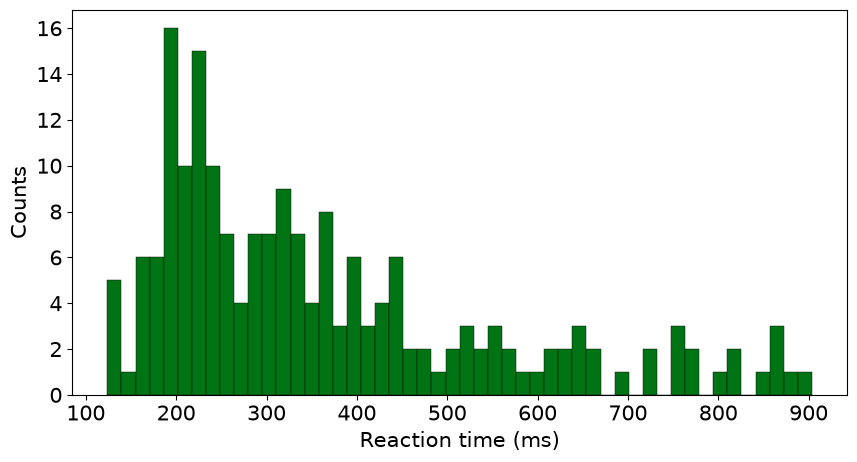

In [10]:
import matplotlib.pyplot as plt

# creating the figure 
f,ax = plt.subplots(1,1,figsize=(10,5))

# get only the hit trials
hit_trials = sessionV1.filter(pl.col("outcome")=="hit")

# get the reaction times as a numpy array
reaction_times = hit_trials["reaction_time"].to_numpy()

_ = ax.hist(reaction_times,bins=50, color="#007415",edgecolor="#000000", linewidth=0.3)
ax.set_ylabel("Counts", fontsize=15)
ax.set_xlabel("Reaction time (ms)", fontsize=15)
ax.tick_params(labelsize=15)

But this is for _all_ of the trials that were hit. In this session we used optogenetic stimulation to see how inhibiting V1 activity impacts visual perception. So, let's compare the distribution for __control (non-optogenetic)__ and __optogenetic__ trials

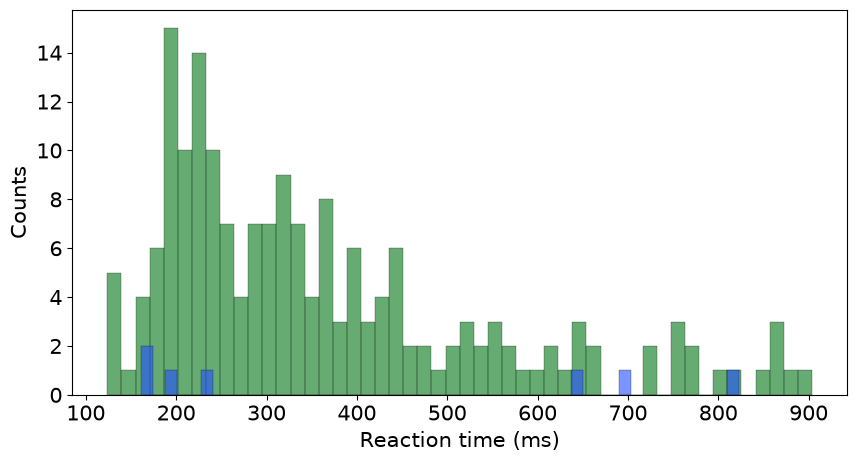

In [11]:
# creating the figure 
f,ax = plt.subplots(1,1,figsize=(10,5))

# seperate the hit rials by opto and non opto
opto_hit_trials = hit_trials.filter(pl.col("opto")==1)
control_hit_trials = hit_trials.filter(pl.col("opto")==0)

# get the reaction times as a numpy array
opto_reaction_times = opto_hit_trials["reaction_time"].to_numpy()
control_reaction_times = control_hit_trials["reaction_time"].to_numpy()

_ = ax.hist(control_reaction_times,bins=50, color="#007415",edgecolor="#000000", linewidth=0.3, alpha=0.6)
_ = ax.hist(opto_reaction_times,bins=50, color="#224FFF",edgecolor="#000000", linewidth=0.3, alpha=0.6)

# We can also mark the median reaction times for both conditions


ax.set_ylabel("Counts", fontsize=15)
ax.set_xlabel("Reaction time (ms)", fontsize=15)
ax.tick_params(labelsize=15)

### Exercise 2:
1. Plot the distributions for all of the trials(not only `hit`). What does the plot tell you about the optogenetic trials?
2. What if we plot two contrast values(`0.125` and `0.5`) side-by-side. For which contrast the optogenetic is more effective?

In [12]:
# your answers here #

### 2.2 Psychometric curve single optogenetic experiment where we silenced the __primary visual cortex (V1)__

A __psychometric curve__ describes how the probability of a particular perceptual response changes as a function of the physical feature of a stimulus (`contrast` in our case). It is commonly used in psychophysics to quantify how sensitive an observer is to a stimulus.

To get the psychometric curve, we first have to calculate the hit rate per contrast level.

hit rate = hit trials / (hit trials + miss trials)

In [13]:
# first get only the contralateral side and trials that were not EARLY
contra_trials = sessionV1.filter((pl.col("stim_side")!="ipsi") & 
                                 (pl.col("outcome")!="early"))

# group the dataset by optogenetic AND contrasts
per_contrast_hr = (contra_trials.group_by(["opto","contrast"])
                   .agg(
                      [
                        pl.col("outcome").filter(pl.col("outcome") == "hit").len().alias("n_hit"),
                        pl.col("outcome").len().alias("n")
                      ]
                   ).sort(["opto","contrast"]))

# calculate the hit rate
per_contrast_hr = per_contrast_hr.with_columns((100*pl.col("n_hit") / pl.col("n")).alias("hit_rate"))

per_contrast_hr

opto,contrast,n_hit,n,hit_rate
bool,f64,u32,u32,f64
false,0.0,1,31,3.225806
false,0.125,28,68,41.176471
false,0.5,70,74,94.594595
true,0.0,0,17,0.0
true,0.125,4,59,6.779661
true,0.5,3,43,6.976744


In [14]:
import numpy as np
from scipy.optimize import curve_fit


def sinusoid(x, amplitude, frequency, phase):
    return amplitude * np.sin(frequency * x + phase)

def weibull(x, guess, lapse, alpha, beta):
    guess + (1 - guess - lapse) * (1 - np.exp(-((x / alpha) ** beta)))

/var/folders/jg/zg43p_f517b7tfj20zr4kfrr0000gn/T/ipykernel_62545/1962838367.py:23: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(sinusoid, contrast, hr, p0=p0)


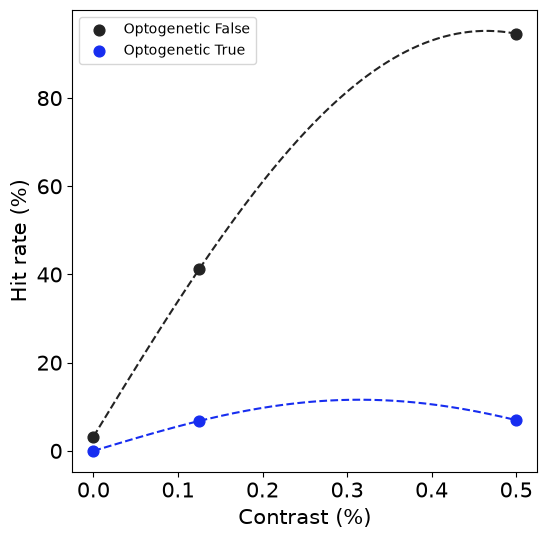

In [15]:
f, ax = plt.subplots(1,1,figsize=(6,6))

for o in [False,True]:
    subset = per_contrast_hr.filter(pl.col("opto")==o)
    
    contrast = subset["contrast"].to_numpy()
    hr = subset["hit_rate"].to_numpy()
    
    ax.scatter(contrast,hr,
               s=60,
               c="#172DF0" if o else "#232323",
               label=f"Optogenetic {o}")
    
    
    # do the fit
    p0 = [
        (hr.max() - hr.min()) / 2,  # amplitude
        1.0,                        # frequency
        0.0,                        # phase
    ]

    # fit
    params, _ = curve_fit(sinusoid, contrast, hr, p0=p0)

    # plot fit
    x_fit = np.linspace(contrast.min(), contrast.max(), 200)
    y_fit = sinusoid(x_fit, *params)

    ax.plot(
        x_fit, y_fit,
        c="#172DF0" if o else "#232323",
        linestyle="--"
    )


ax.set_ylabel("Hit rate (%)", fontsize=15)
ax.set_xlabel("Contrast (%)", fontsize=15)
ax.tick_params(labelsize=15)
ax.legend()

## Exercise 3
1. Fit another function to the data, you can try the Weibull function below:

$$
P(x) = \gamma + (1-\gamma-\lambda)
\left[
1-\exp\left(-\left(\frac{x}{\alpha}\right)^\beta\right)
\right]
$$

where,
$$
\begin{aligned}
&x = stimulus contrast\\
&\gamma = guessing rate\\
&\lambda = lapse rate\\
&\alpha = threshold\\
&\beta = slope
\end{aligned}
$$



In [16]:
# your answer here #

## 3. Quantifying the effects of inhibition in a cohort

To be able to have scientifically robust conclusions, it's necessary to have a cohort of subjects to see that the effects we observed are statistically significant.

To see if we can conclude that V1 is required for perception of stimuli, like our above results suggest, we have to look at the result of multiple experiments from multiple animals.

We can group our dataset by animals and see if the optogenetic effects hold.

In [28]:
AREAS = ["V1","HVA","dorsal","ventralPM"]

# filter the data to only have contralateral, 0.5 contrast
sided_data = behavioral_data.filter((pl.col("stim_side")=="contra") & 
                                    (pl.col("contrast")==0.5) & 
                                    (pl.col("stim_combination")=="0.04cpd_8.0Hz+0.16cpd_0.5Hz") &
                                    (pl.col("area").is_in(AREAS)))

# group the data 
grouped_data = (sided_data.group_by(["animalid","area","stim_type","isCNO","opto"])
                .agg(
                    pl.col("outcome").filter(pl.col("outcome") == "hit").len().alias("n_hit"),
                    pl.col("outcome").len().alias("n"),
                    pl.col("reaction_time").median().alias("median_reaction_time")
                ).sort(["animalid","area","stim_type","isCNO","opto"]))

# calculate the hit rate
grouped_data = grouped_data.with_columns((100*pl.col("n_hit") / pl.col("n")).alias("hit_rate"))

grouped_data

animalid,area,stim_type,isCNO,opto,n_hit,n,median_reaction_time,hit_rate
str,str,str,bool,bool,u32,u32,f64,f64
"""KC143""","""HVA""","""0.04cpd_8.0Hz""",false,false,15,16,153.4,93.75
"""KC143""","""HVA""","""0.04cpd_8.0Hz""",false,true,7,30,882.5,23.333333
"""KC143""","""HVA""","""0.16cpd_0.5Hz""",false,false,11,12,159.1,91.666667
"""KC143""","""HVA""","""0.16cpd_0.5Hz""",false,true,0,27,901.0,0.0
"""KC143""","""V1""","""0.04cpd_8.0Hz""",false,false,25,26,175.5,96.153846
…,…,…,…,…,…,…,…,…
"""KC152""","""ventralPM""","""0.04cpd_8.0Hz""",true,true,1,18,503.2,5.555556
"""KC152""","""ventralPM""","""0.16cpd_0.5Hz""",false,false,12,24,199.8,50.0
"""KC152""","""ventralPM""","""0.16cpd_0.5Hz""",false,true,2,31,84.0,6.451613


### 3.1 Plotting the impact of optogenetic stimulation in CNO conditions

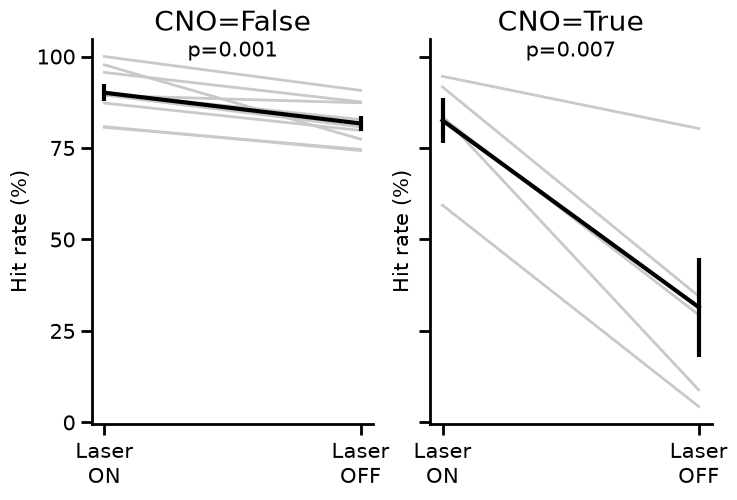

In [63]:
import scipy.stats as sts

STIM_TYPE = "0.04cpd_8.0Hz"
AREA = "dorsal"

#create the figure
f, axs = plt.subplots(1,2, figsize=(8,5), sharey=True)

# filter subset of data for stimulus type and area
plot_data = grouped_data.filter((pl.col("area")==AREA) &
                                (pl.col("stim_type")==STIM_TYPE))

# unique values in columns to loop through
uniq_CNO = plot_data["isCNO"].unique(maintain_order=True)
uniq_opto = plot_data["opto"].unique(maintain_order=True)


for cno, ax in zip(uniq_CNO, axs):
    cno_data = plot_data.filter(pl.col("isCNO")==cno)
    
    opto_arr = cno_data["hit_rate"].to_numpy().reshape(-1, 2)
    
    # plot individual animals
    ax.plot([0,1],opto_arr.T, color="#c9c9c9",linewidth=2)
    
    # plot the means and SEMs
    means = np.nanmean(opto_arr,axis=0)
    sems = sts.sem(opto_arr,axis=0,nan_policy="omit")
    
    ax.errorbar([0,1],means,yerr=sems, color="#000000", linewidth=3)
    
    
    # calculate the p-value
    pval = sts.ttest_rel(opto_arr[:,0],opto_arr[:,1],nan_policy="omit").pvalue
    ax.text(0.5,100,f"p={pval:.3f}",ha="center",color="#000000",fontsize=15)
    
    # make the plot pretty
    ax.set_title(f"CNO={cno}",fontsize=20)
    ax.set_ylabel("Hit rate (%)",fontsize=15)
    ax.tick_params(labelsize=15, width=2,length=8)
    
    ax.set_xticks([0,1])
    ax.set_xticklabels(["Laser\nON", "Laser\nOFF"])
    
    ax.set_yticks([0,25,50,75,100])
    
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)